# Vorhersage von Airbnb-Preisen in London

Dieses Notebook analysiert Airbnb-Inserate in London und entwickelt Modelle zur Vorhersage des Nachtpreises. Die Analyse gliedert sich in sechs Abschnitte:

1. **Datenaufbereitung** – Einlesen, Bereinigen und Feature Engineering
2. **Deskriptive Statistik** – Verteilungen, geografische Muster und Zusammenhänge
3. **Hypothesentest** – Preisunterschied zwischen Superhosts und regulären Gastgebern
4. **Lineare Regression** – Inferenzstatistik mit Koeffizienten, p-Werten und R²
5. **Machine-Learning-Analyse** – XGBoost, Lineare Regression, Ridge, Neuronales Netz
6. **Kritische Bewertung** – Diskussion, Limitierungen und Handlungsempfehlungen

In [1]:
# Bibliotheken laden
import pandas as pd
import numpy as np
import ast
import seaborn as sns
import xgboost as xgb
import optuna
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy import stats
from sklearn.model_selection import train_test_split, KFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.linear_model import LinearRegression, RidgeCV
from sklearn.neural_network import MLPRegressor
from collections import Counter
optuna.logging.set_verbosity(optuna.logging.WARNING)

## 1. Datenaufbereitung

Der Rohdatensatz enthält Informationen zu Airbnb-Inseraten in London. In diesem Abschnitt werden relevante Merkmale ausgewählt, kategorische Variablen kodiert, Koordinaten in ein Entfernungs-Feature umgerechnet und Ausreißer entfernt.

In [2]:
# Konstanten
file_path = 'data.csv'
columns = [
    # 'id', 'name',

    # ── Gastgeber ─────────────────────────────────────────────────────────────
    'host_is_superhost',              # Erfahrener, hoch bewerteter Gastgeber – kann einen Preisaufschlag erzielen

    # ── Standort (wird später in Distanz zum Zentrum umgerechnet) ─────────────
    'latitude', 'longitude',          # Rohe Koordinaten → werden in Luftlinien-Entfernung zum Stadtzentrum umgerechnet

    # ── Unterkunftstyp & Größe ────────────────────────────────────────────────
    'room_type',                      # Ganze Wohnung vs. Privatzimmer – stärkster kategorialer Preistreiber
    'accommodates',                   # Maximale Gästezahl – wichtigstes Größenmerkmal und Preistreiber
    'bathrooms',                      # Mehr Badezimmer = größeres, hochwertigeres Objekt
    'bathrooms_text',                 # Rohtext zur Unterscheidung: geteiltes vs. privates Bad
    'bedrooms',                       # Anzahl der Schlafzimmer – ergänzt accommodates bei der Größeneinschätzung
    # 'beds' bewusst ausgeschlossen – Korrelation 0,805 mit accommodates (redundant)

    # ── Ausstattung ───────────────────────────────────────────────────────────
    'amenities',                      # Rohe Textliste → wird in amenity_count und binäre has_*-Flags umgewandelt

    # ── Zielvariable ──────────────────────────────────────────────────────────
    'price',                          # Nachtpreis in USD – die Variable, die wir vorhersagen wollen

    # ── Qualitäts- und Nachfragesignale ───────────────────────────────────────
    'review_scores_location',         # Von Gästen bewertete Lage (1–5); erfasst wahrgenommene Attraktivität
                                      # über den Stadtbezirk hinaus. Stärkeres Signal als review_scores_rating
                                      # (Korr. +0,132 vs. +0,032 mit dem Preis).
    'availability_365',               # Verfügbare Tage pro Jahr – Indikator für aktive Preisgestaltung

    # ── Geografie ─────────────────────────────────────────────────────────────
    'neighbourhood_cleansed',         # Standardisierter Londoner Stadtbezirk → wird in 33 binäre Spalten umkodiert

    # ── Professionalität des Gastgebers ───────────────────────────────────────
    'calculated_host_listings_count', # Anzahl aktiver Inserate dieses Gastgebers – unterscheidet professionelle
                                      # Betreiber (viele Inserate, strategische Preisgestaltung) von Privatpersonen.
                                      # Stärkstes ungenutztes Signal (Korr. +0,218 mit dem Preis).
]
# Quelle: https://www.latlong.net/place/london-uk-14153.html
london_center_lat = 51.509865
london_center_lon = -0.118092

# Zufalls-Seeds – das Modell wird einmal pro Seed trainiert und ausgewertet.
# Der Durchschnitt über alle Seeds liefert eine zuverlässigere Leistungsschätzung
# als ein einzelner Durchlauf.
seeds = [1, 7, 42, 67, 99]

In [3]:
# Rohdatensatz einlesen
df = pd.read_csv(file_path)

In [4]:
# Vollständige Ausgabe des DataFrames – nützlich zur ersten Übersicht
print(df.columns.tolist())
print(df.head())

['id', 'listing_url', 'scrape_id', 'last_scraped', 'source', 'name', 'description', 'neighborhood_overview', 'picture_url', 'host_id', 'host_url', 'host_name', 'host_since', 'host_location', 'host_about', 'host_response_time', 'host_response_rate', 'host_acceptance_rate', 'host_is_superhost', 'host_thumbnail_url', 'host_picture_url', 'host_neighbourhood', 'host_listings_count', 'host_total_listings_count', 'host_verifications', 'host_has_profile_pic', 'host_identity_verified', 'neighbourhood', 'neighbourhood_cleansed', 'neighbourhood_group_cleansed', 'latitude', 'longitude', 'property_type', 'room_type', 'accommodates', 'bathrooms', 'bathrooms_text', 'bedrooms', 'beds', 'amenities', 'price', 'minimum_nights', 'maximum_nights', 'minimum_minimum_nights', 'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights', 'minimum_nights_avg_ntm', 'maximum_nights_avg_ntm', 'calendar_updated', 'has_availability', 'availability_30', 'availability_60', 'availability_90', 'availabil

In [5]:
# Nur relevante Spalten behalten und Zeilen mit fehlenden Werten entfernen
df = df[columns].dropna()

In [6]:
# Stadtbezirks-Spalte vor der Kodierung erkunden
print(df['neighbourhood_cleansed'].nunique())             # Wie viele einzigartige Stadtbezirke?
print(df['neighbourhood_cleansed'].value_counts().head(10))

33
neighbourhood_cleansed
Westminster               6240
Kensington and Chelsea    3505
Camden                    3419
Tower Hamlets             3284
Hackney                   2520
Southwark                 2412
Wandsworth                2336
Lambeth                   2245
Islington                 2179
Hammersmith and Fulham    2097
Name: count, dtype: int64


In [7]:
# One-Hot-Kodierung der Stadtbezirks-Spalte:
# Jeder Stadtbezirk erhält eine eigene 0/1-Spalte (z. B. nb_Westminster = 1, wenn das Inserat dort liegt).
nb_dummies = pd.get_dummies(df['neighbourhood_cleansed'], prefix='nb', dtype=int)
df = pd.concat([df, nb_dummies], axis=1)
df = df.drop(columns='neighbourhood_cleansed')

In [8]:
def calculate_haversine_distance(lat_series, lon_series, center_lat, center_lon):
    """
    Berechnet die Luftlinien-Entfernung (in Metern) zwischen jedem Inserat und einem festen Punkt.

    Verwendet die Haversine-Formel, die die Erdkrümmung korrekt berücksichtigt.
    Die Funktion ist vektorisiert – sie verarbeitet die gesamte Spalte auf einmal (sehr schnell).
    """
    R = 6371000.0  # Erdradius in Metern

    # Grad in Bogenmaß umrechnen (für trigonometrische Funktionen erforderlich)
    phi1         = np.radians(lat_series)
    phi2         = np.radians(center_lat)
    delta_phi    = np.radians(center_lat - lat_series)
    delta_lambda = np.radians(center_lon - lon_series)

    # Haversine-Formel
    a = np.sin(delta_phi / 2.0)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(delta_lambda / 2.0)**2
    c = 2 * np.arctan2(np.sqrt(a), np.sqrt(1 - a))

    return R * c

In [9]:
# Koordinaten für die spätere geografische Visualisierung sichern
_geo_lat = df['latitude'].copy()
_geo_lon = df['longitude'].copy()

# Rohe Koordinaten durch Entfernungs-Feature ersetzen (Meter zum Stadtzentrum)
df['distance_to_center_m'] = calculate_haversine_distance(
    df['latitude'], df['longitude'],
    london_center_lat, london_center_lon
).round()

df = df.drop(columns=['latitude', 'longitude'])

In [10]:
print(df.dtypes)

host_is_superhost                     str
room_type                             str
accommodates                        int64
bathrooms                         float64
bathrooms_text                        str
bedrooms                          float64
amenities                             str
price                                 str
review_scores_location            float64
availability_365                    int64
calculated_host_listings_count      int64
nb_Barking and Dagenham             int64
nb_Barnet                           int64
nb_Bexley                           int64
nb_Brent                            int64
nb_Bromley                          int64
nb_Camden                           int64
nb_City of London                   int64
nb_Croydon                          int64
nb_Ealing                           int64
nb_Enfield                          int64
nb_Greenwich                        int64
nb_Hackney                          int64
nb_Hammersmith and Fulham         

In [11]:
# Textwerte 't'/'f' in 1/0-Ganzzahlen umwandeln (1 = ist Superhost)
df['host_is_superhost'] = (df['host_is_superhost'] == 't').astype(int)

In [12]:
# Unterkunftstyp in vier separate 0/1-Spalten umkodieren (One-Hot-Encoding)
print(df['room_type'].unique())
df["is_private_room"] = (df["room_type"] == "Private room").astype(int)
df["is_entire_home"]  = (df["room_type"] == "Entire home/apt").astype(int)
df["is_hotel_room"]   = (df["room_type"] == "Hotel room").astype(int)
df["is_shared_room"]  = (df["room_type"] == "Shared room").astype(int)

df = df.drop(columns=['room_type'])

<StringArray>
['Private room', 'Entire home/apt', 'Hotel room', 'Shared room']
Length: 4, dtype: str


In [13]:
# Seltene Unterkunftstypen entfernen – Hotel (41 Inserate) und Shared (111 Inserate)
# sind zu wenige, um daraus verlässliche Muster zu lernen.
df = df[(df['is_hotel_room'] == False) & (df['is_shared_room'] == False)]
df = df.drop(columns=['is_hotel_room', 'is_shared_room'])

In [14]:
# Preisspalte bereinigen: '$'- und ','-Zeichen entfernen, dann in numerischen Float umwandeln
df['price_dollar'] = (df['price']
                      .str.replace("$", "", regex=False)
                      .str.replace(",", "", regex=False)
                      .str.replace(".00", "", regex=False)
                      .astype(float))
df = df.drop(columns=['price'])

In [15]:
# 1/0-Flag erstellen: 1 = geteiltes Bad, 0 = privates Bad
df['is_shared_bath'] = df['bathrooms_text'].str.contains('shared', case=False, na=False).astype(int)
df = df.drop(columns='bathrooms_text')

In [16]:
# Extreme Preisausreißer entfernen – Inserate unter 10 $/Nacht und über 1.000 $/Nacht sind wahrscheinlich Datenfehler
df = df[df['price_dollar'] < 1000]
df = df[df['price_dollar'] >= 10]

In [17]:
# ── Extraktion der Ausstattungsmerkmale ───────────────────────────────────────
#
# Die rohe amenities-Spalte ist ein Text, der wie eine Python-Liste aussieht:
#   '["Wifi", "Kitchen", "Private pool", ...]'
#
# Daraus entstehen zwei Arten von Features:
#   1. amenity_count  – Gesamtanzahl der Ausstattungsmerkmale (mehr = hochwertigeres Inserat)
#   2. has_*          – Binäres Flag für relevante Einzelmerkmale
#
# has_wifi (98,3 %) und has_kitchen (91,5 %) wurden entfernt –
# quasi-konstante Features liefern kaum Information und verschwenden Modellkapazität.

def parse_amenities(val):
    """Den Amenities-Text in eine Python-Liste umwandeln."""
    if isinstance(val, list):
        return val
    if isinstance(val, str):
        try:
            return ast.literal_eval(val)
        except (ValueError, SyntaxError):
            return []
    return []

amenities_lists = df['amenities'].apply(parse_amenities)

# Gesamtanzahl der Ausstattungsmerkmale pro Inserat
df['amenity_count'] = amenities_lists.apply(len)

# Gezielte binäre Flags – Groß-/Kleinschreibung wird ignoriert, um Varianten wie
# "Private pool", "Patio or balcony" oder "Hot tub/Jacuzzi" zu erfassen.
targeted_amenities = {
    'has_pool':    lambda lst: any('pool' in a.lower() for a in lst),
    'has_hot_tub': lambda lst: any('hot tub' in a.lower() or 'jacuzzi' in a.lower() for a in lst),
    'has_bathtub': lambda lst: any('bathtub' in a.lower() for a in lst),
    'has_balcony': lambda lst: any('balcony' in a.lower() or 'patio' in a.lower() for a in lst),
}

for col, check in targeted_amenities.items():
    df[col] = amenities_lists.apply(check).astype(int)
    n = df[col].sum()
    print(f"{col:<15} {n:>6,} Inserate  ({n / len(df) * 100:.1f}%)")

print(f"\namenity_count:  Mittelwert={df['amenity_count'].mean():.1f}  "
      f"Min={df['amenity_count'].min()}  Max={df['amenity_count'].max()}")

# Rohe Textspalte entfernen – alle Informationen wurden bereits extrahiert
df = df.drop(columns='amenities')

# Inserate ohne jegliche Ausstattungsangaben entfernen – amenity_count == 0
# deutet auf fehlende oder fehlerhafte Daten hin, nicht auf eine echte leere Ausstattung.
n_before = len(df)
df = df[df['amenity_count'] > 0]
print(f"\nInserate ohne Ausstattungsangaben entfernt: {n_before - len(df):,}  →  {len(df):,} verbleibend")

has_pool           538 Inserate  (1.2%)


has_hot_tub        858 Inserate  (1.9%)
has_bathtub     21,203 Inserate  (45.8%)


has_balcony     11,601 Inserate  (25.1%)

amenity_count:  Mittelwert=33.4  Min=0  Max=96

Inserate ohne Ausstattungsangaben entfernt: 12  →  46,236 verbleibend


## 2. Deskriptive Statistik

Überblick über die Verteilung des Nachtpreises und der wichtigsten Merkmale. Histogramme, eine geografische Karte und Streudiagramme helfen, Muster und Zusammenhänge im Datensatz zu erkennen. Abschließend wird die Korrelationsstruktur aller Features analysiert.

In [18]:
summary_cols = [
    'price_dollar', 'accommodates', 'bedrooms', 'bathrooms',
    'distance_to_center_m', 'review_scores_location',
    'availability_365', 'calculated_host_listings_count', 'amenity_count',
]
df[summary_cols].describe().round(2).style.set_caption("Deskriptive Statistik – ausgewählte Merkmale")

,price_dollar,accommodates,bedrooms,bathrooms,distance_to_center_m,review_scores_location,availability_365,calculated_host_listings_count,amenity_count
count,46236.000000,46236.000000,46236.000000,46236.000000,46236.000000,46236.000000,46236.000000,46236.000000,46236.000000
mean,165.270000,3.500000,1.520000,1.330000,7529.210000,4.720000,203.300000,16.100000,33.380000
std,132.290000,2.130000,0.940000,0.620000,4926.720000,0.420000,120.380000,40.540000,14.000000
min,10.000000,1.000000,0.000000,0.000000,59.000000,1.000000,0.000000,1.000000,1.000000
25%,76.000000,2.000000,1.000000,1.000000,3852.000000,4.640000,88.000000,1.000000,23.000000
50%,130.000000,3.000000,1.000000,1.000000,6283.500000,4.830000,222.000000,3.000000,34.000000
75%,207.000000,4.000000,2.000000,1.500000,10036.000000,5.000000,320.000000,13.000000,43.000000
max,999.000000,16.000000,12.000000,12.000000,29135.000000,5.000000,365.000000,500.000000,96.000000


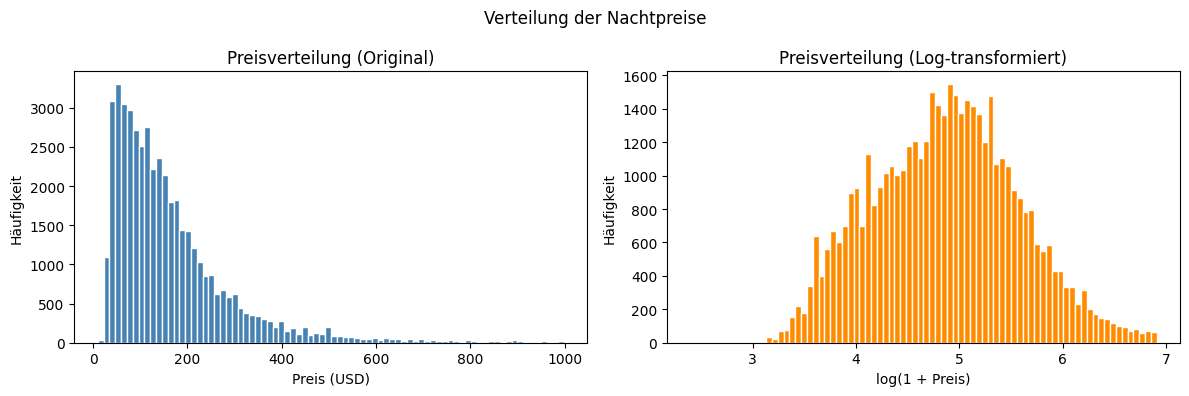

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(df['price_dollar'], bins=80, color='steelblue', edgecolor='white')
axes[0].set_xlabel('Preis (USD)')
axes[0].set_ylabel('Häufigkeit')
axes[0].set_title('Preisverteilung (Original)')

axes[1].hist(np.log1p(df['price_dollar']), bins=80, color='darkorange', edgecolor='white')
axes[1].set_xlabel('log(1 + Preis)')
axes[1].set_ylabel('Häufigkeit')
axes[1].set_title('Preisverteilung (Log-transformiert)')

plt.suptitle('Verteilung der Nachtpreise')
plt.tight_layout()
plt.show()

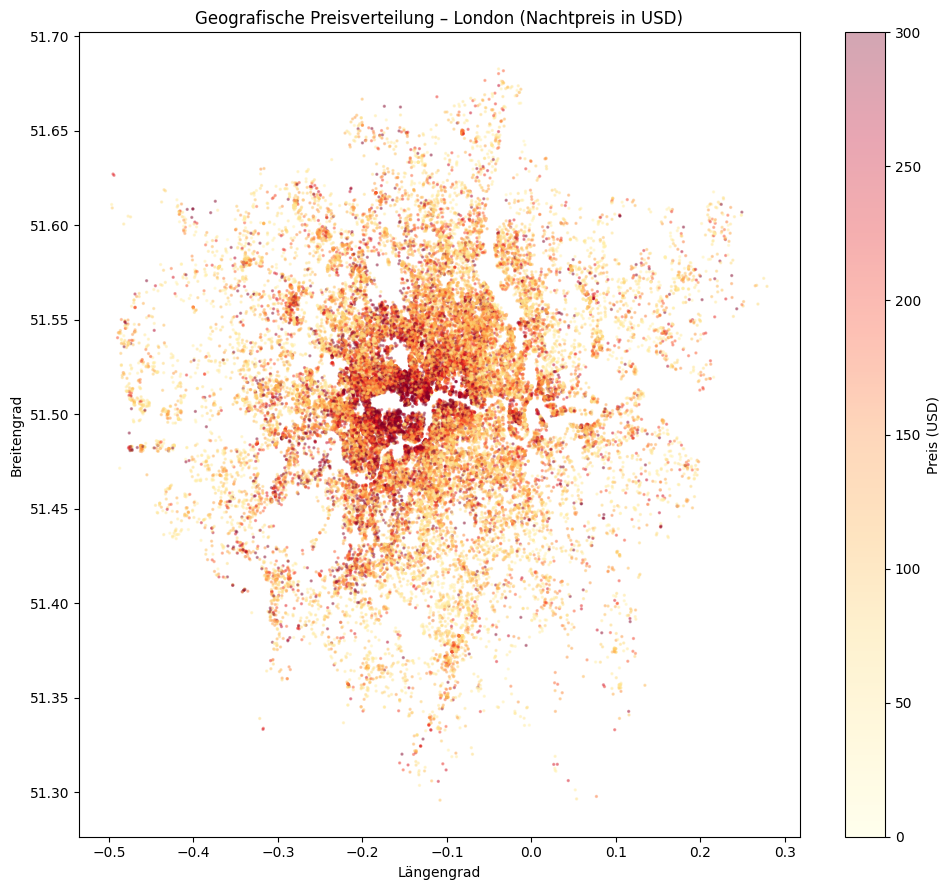

In [20]:
fig, ax = plt.subplots(figsize=(10, 9))
sc = ax.scatter(
    _geo_lon.loc[df.index], _geo_lat.loc[df.index],
    c=df['price_dollar'], cmap='YlOrRd',
    alpha=0.35, s=2, vmin=0, vmax=300,
)
plt.colorbar(sc, ax=ax, label='Preis (USD)')
ax.set_xlabel('Längengrad')
ax.set_ylabel('Breitengrad')
ax.set_title('Geografische Preisverteilung – London (Nachtpreis in USD)')
plt.tight_layout()
plt.show()

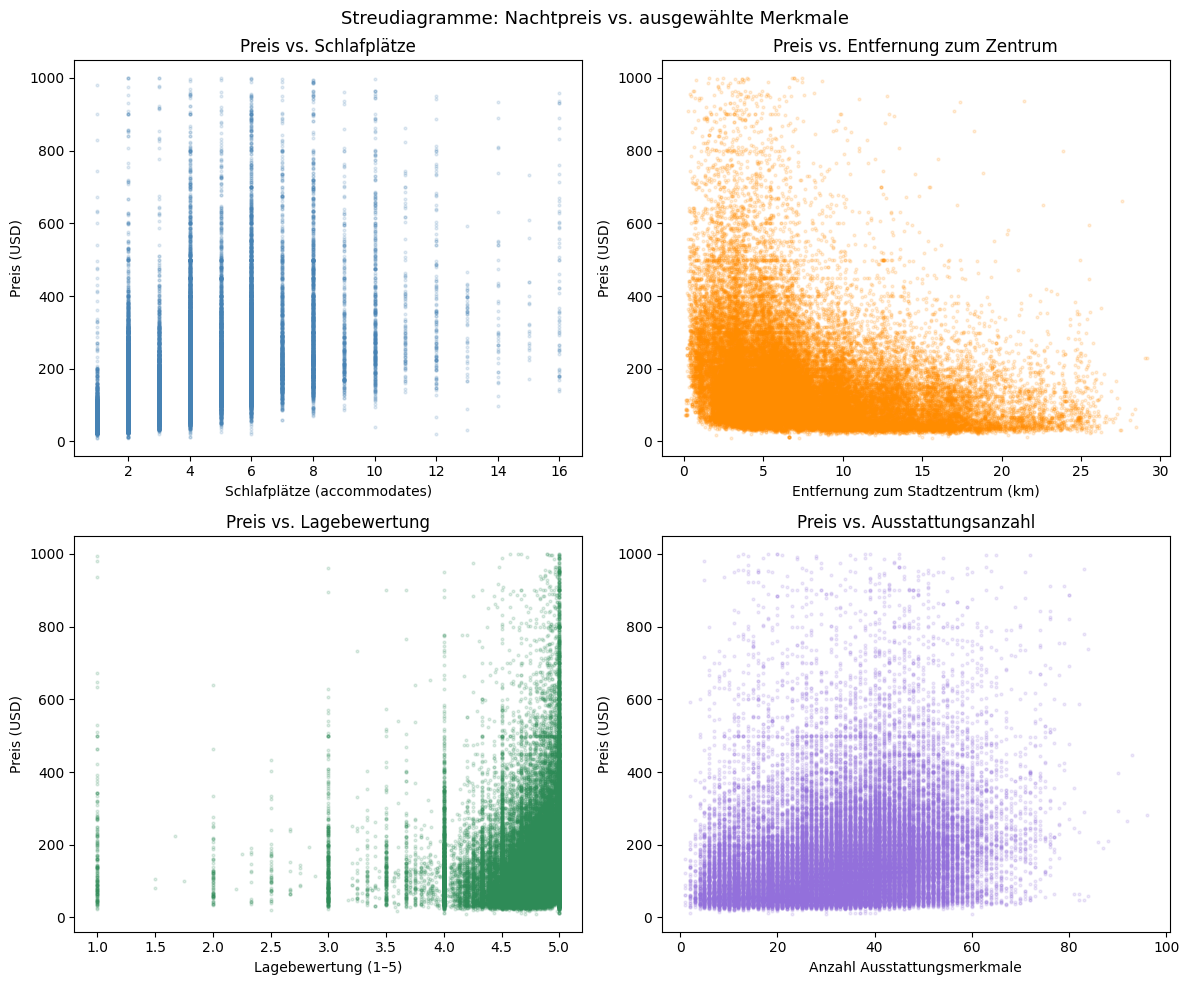

In [21]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

axes[0, 0].scatter(df['accommodates'], df['price_dollar'], alpha=0.15, s=4, color='steelblue')
axes[0, 0].set_xlabel('Schlafplätze (accommodates)')
axes[0, 0].set_ylabel('Preis (USD)')
axes[0, 0].set_title('Preis vs. Schlafplätze')

axes[0, 1].scatter(df['distance_to_center_m'] / 1000, df['price_dollar'], alpha=0.15, s=4, color='darkorange')
axes[0, 1].set_xlabel('Entfernung zum Stadtzentrum (km)')
axes[0, 1].set_ylabel('Preis (USD)')
axes[0, 1].set_title('Preis vs. Entfernung zum Zentrum')

axes[1, 0].scatter(df['review_scores_location'], df['price_dollar'], alpha=0.15, s=4, color='seagreen')
axes[1, 0].set_xlabel('Lagebewertung (1–5)')
axes[1, 0].set_ylabel('Preis (USD)')
axes[1, 0].set_title('Preis vs. Lagebewertung')

axes[1, 1].scatter(df['amenity_count'], df['price_dollar'], alpha=0.15, s=4, color='mediumpurple')
axes[1, 1].set_xlabel('Anzahl Ausstattungsmerkmale')
axes[1, 1].set_ylabel('Preis (USD)')
axes[1, 1].set_title('Preis vs. Ausstattungsanzahl')

plt.suptitle('Streudiagramme: Nachtpreis vs. ausgewählte Merkmale', fontsize=13)
plt.tight_layout()
plt.show()

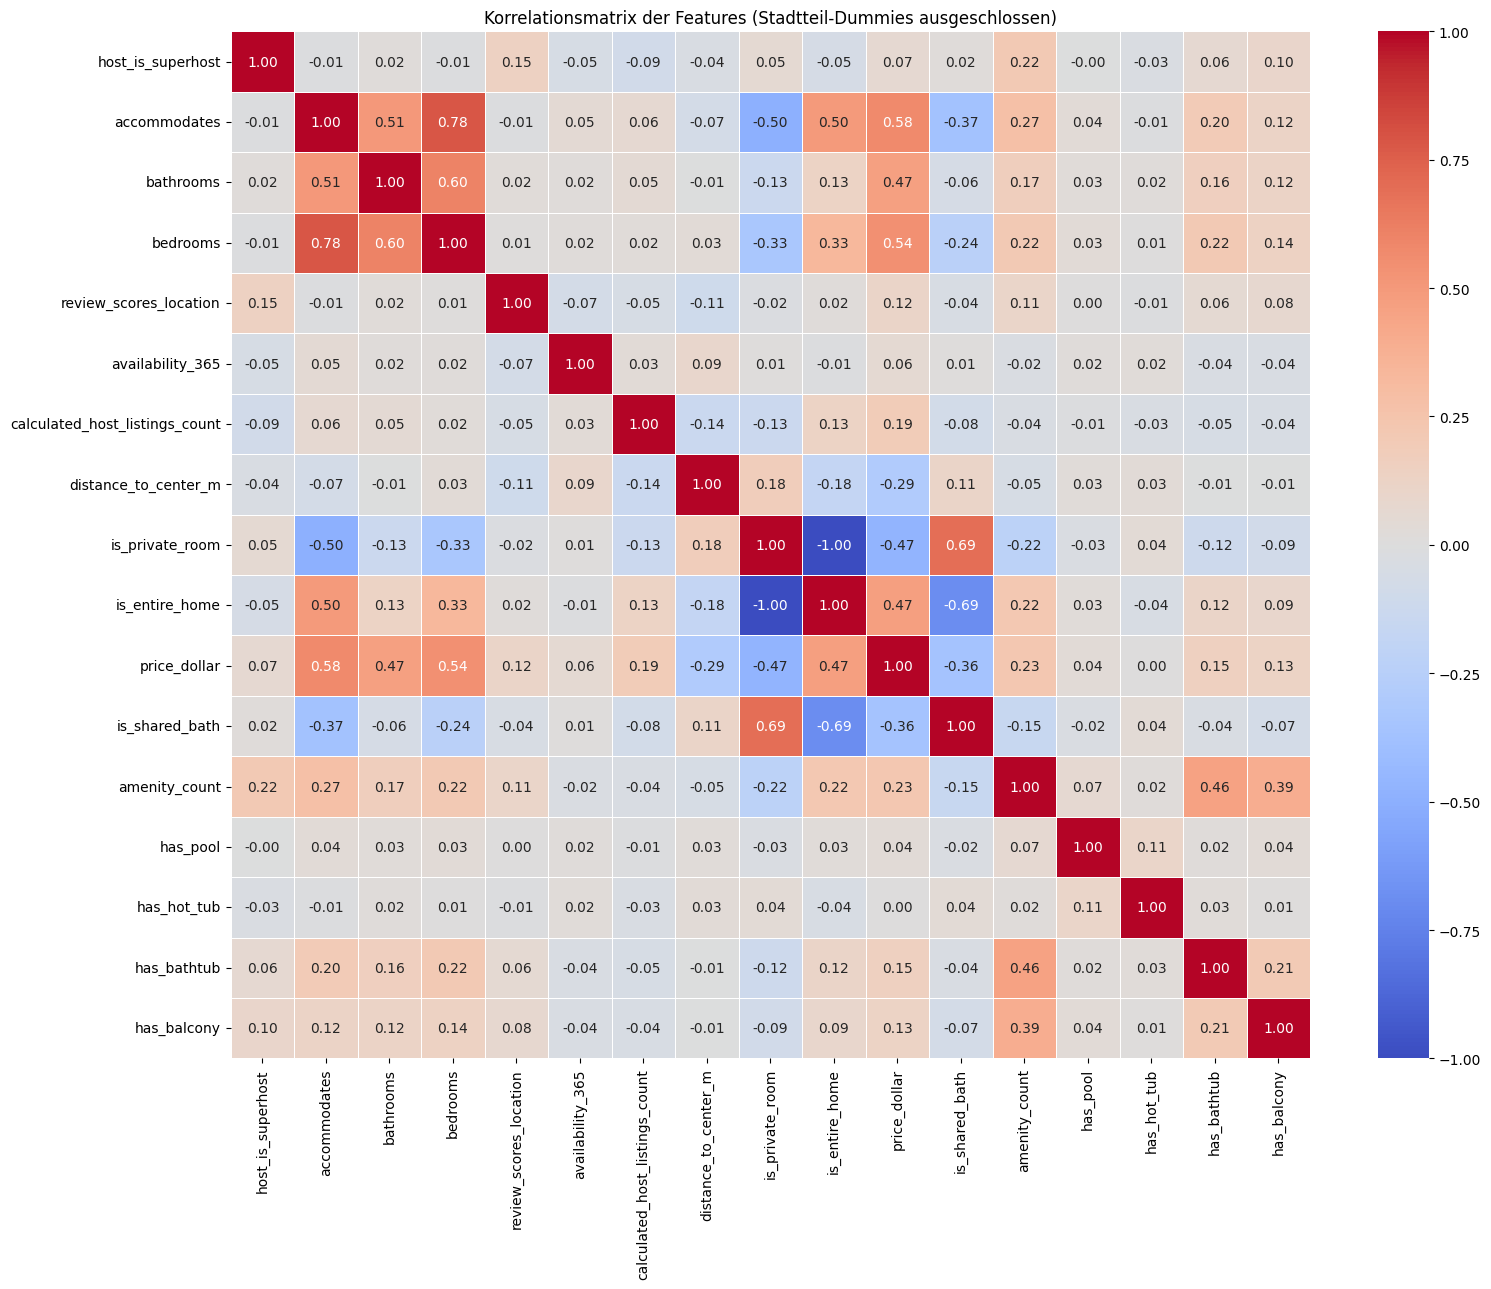

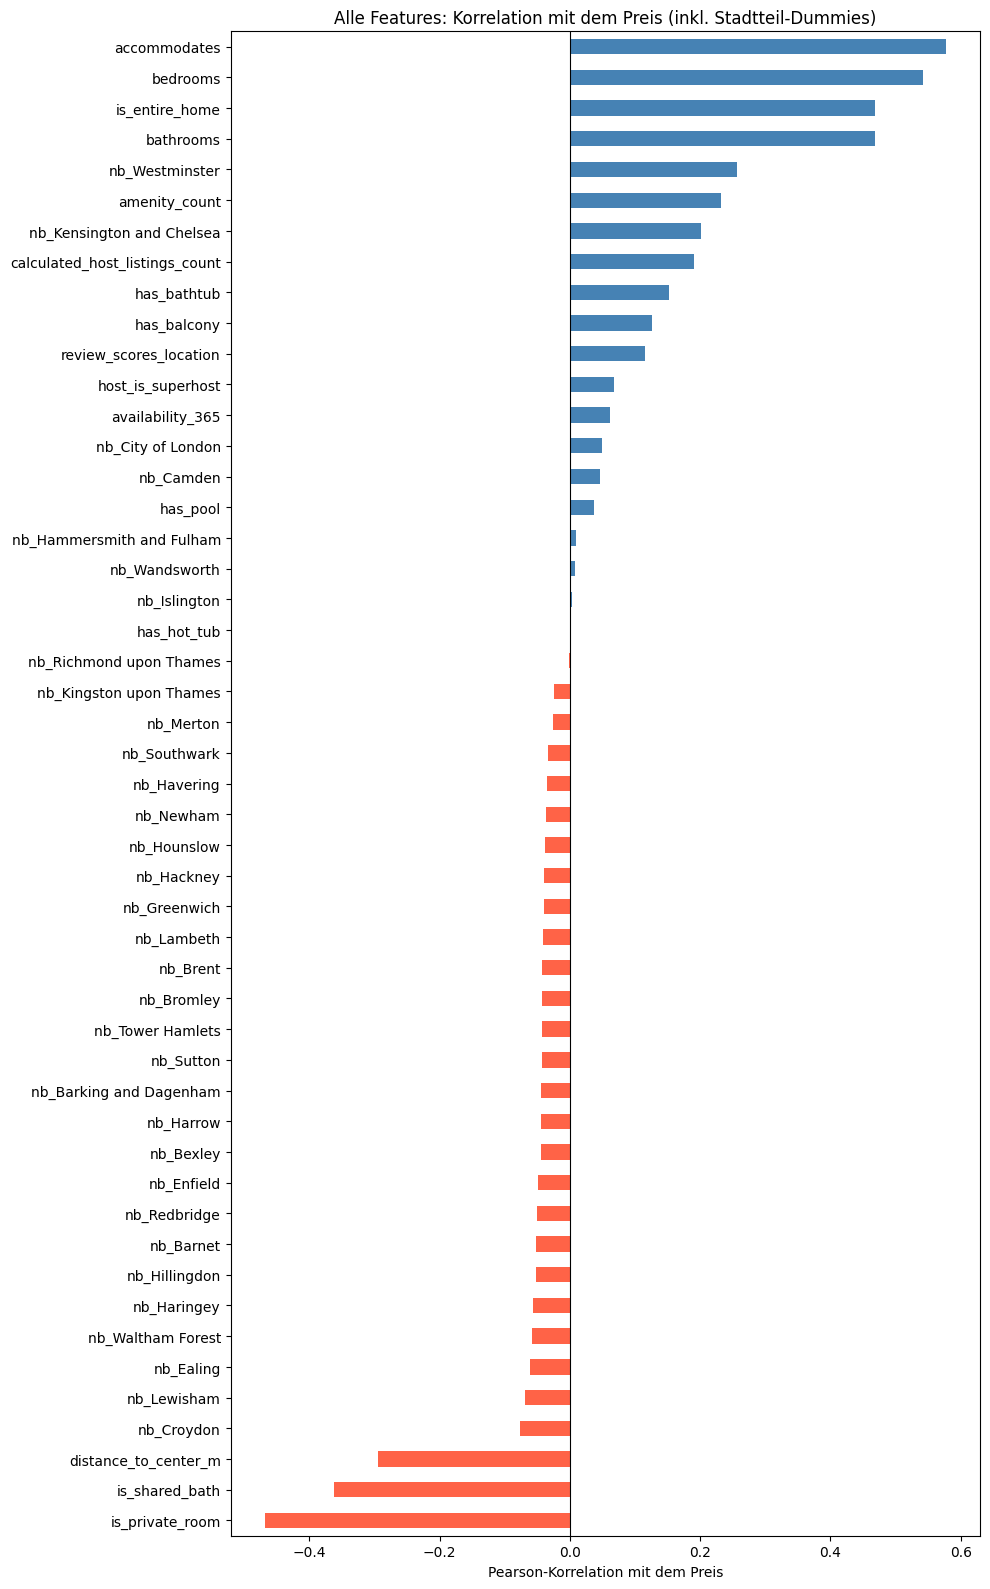

In [22]:
# ── Korrelationsanalyse der Features ──────────────────────────────────────────
#
# Diagramm 1 – Heatmap aller erstellten Features (Stadtteil-Dummies ausgeschlossen).
#   Die 33 nb_*-Spalten sind One-Hot-kodiert und schließen sich gegenseitig aus.
#   Ihre Kreuzkorrelationen sind daher nichtssagend und würden die Matrix unleserlich machen.
#
# Diagramm 2 – Balkendiagramm der Korrelation ALLER Features mit dem Preis,
#   einschließlich der Stadtteil-Dummies. Zeigt, welche Stadtbezirke den Preis erhöhen oder senken.

non_dummy_cols = [c for c in df.columns if not c.startswith('nb_')]
corr_matrix = df[non_dummy_cols].corr()

fig, ax = plt.subplots(figsize=(16, 13))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.4,
    ax=ax,
)
ax.set_title('Korrelationsmatrix der Features (Stadtteil-Dummies ausgeschlossen)')
plt.tight_layout()
plt.show()

# ── Alle Features vs. Preis (inkl. Stadtteil-Dummies) ────────────────────────
price_corr = df.corr(numeric_only=True)['price_dollar'].drop('price_dollar').sort_values()

colors = ['tomato' if v < 0 else 'steelblue' for v in price_corr]
fig, ax = plt.subplots(figsize=(10, 16))
price_corr.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson-Korrelation mit dem Preis')
ax.set_title('Alle Features: Korrelation mit dem Preis (inkl. Stadtteil-Dummies)')
plt.tight_layout()
plt.show()

## 3. Hypothesentest

**Fragestellung:** Erzielen Superhosts signifikant höhere Preise als reguläre Gastgeber?

Superhosts sind erfahrene, hoch bewertete Gastgeber mit einem besonderen Status auf der Plattform. Die Vermutung liegt nahe, dass sie für ihre Qualität einen Preisaufschlag verlangen können.

- **H₀:** Mittlerer Preis von Superhosts = Mittlerer Preis der Nicht-Superhosts (μ₁ = μ₂)
- **H₁:** Die mittleren Preise unterscheiden sich (μ₁ ≠ μ₂)

Verwendet wird der **Welch-t-Test** (zweiseitig, α = 0,05), der keine gleichen Varianzen voraussetzt und damit robuster als der klassische t-Test ist.

In [23]:
superhost_prices     = df.loc[df['host_is_superhost'] == 1, 'price_dollar']
non_superhost_prices = df.loc[df['host_is_superhost'] == 0, 'price_dollar']

t_stat, p_value = stats.ttest_ind(superhost_prices, non_superhost_prices, equal_var=False)

print(f"{'Gruppe':<22} {'n':>7}   {'Mittl. Preis ($)':>16}   {'Std.-Abw. ($)':>13}")
print('─' * 65)
print(f"{'Superhost':<22} {len(superhost_prices):>7,}   "
      f"${superhost_prices.mean():>15.2f}   ${superhost_prices.std():>12.2f}")
print(f"{'Kein Superhost':<22} {len(non_superhost_prices):>7,}   "
      f"${non_superhost_prices.mean():>15.2f}   ${non_superhost_prices.std():>12.2f}")

direction = 'höhere' if superhost_prices.mean() > non_superhost_prices.mean() else 'niedrigere'
print(f'\nWelch-t-Test:')
print(f'  t-Statistik : {t_stat:>10.4f}')
print(f'  p-Wert      : {p_value:>10.6f}')
if p_value < 0.05:
    print(f'\n→ H₀ abgelehnt (p < 0.05): Superhosts erzielen statistisch signifikant {direction} Preise.')
else:
    print('\n→ H₀ nicht abgelehnt (p ≥ 0.05): Kein signifikanter Preisunterschied nachweisbar.')

Gruppe                       n   Mittl. Preis ($)   Std.-Abw. ($)
─────────────────────────────────────────────────────────────────
Superhost               13,274   $         179.51   $      150.96
Kein Superhost          32,962   $         159.53   $      123.52

Welch-t-Test:
  t-Statistik :    13.5348
  p-Wert      :   0.000000

→ H₀ abgelehnt (p < 0.05): Superhosts erzielen statistisch signifikant höhere Preise.


## 4. Lineare Regression

Das Modell wird auf dem **gesamten Datensatz** (ohne Train/Test-Aufteilung) geschätzt, um für jeden Koeffizienten Standardfehler, t-Statistik und p-Wert zu ermitteln.

**Interpretation der Koeffizienten:** Da die Zielvariable log(1 + Preis) ist, entspricht ein Koeffizient β einem multiplikativen Preiseffekt von e^β. Ein Koeffizient von 0,10 bedeutet näherungsweise +10 % im Preis.

**Statistische Signifikanz:** Ein Merkmal gilt als signifikant, wenn der p-Wert < 0,05 – die Nullhypothese (β = 0, kein Effekt) wird dann verworfen.

In [24]:
X_ols = df.drop(columns='price_dollar')
X_ols = sm.add_constant(X_ols)
y_ols = np.log1p(df['price_dollar'])

ols = sm.OLS(y_ols, X_ols).fit()
print(ols.summary())

# Significant non-dummy coefficients with multiplicative interpretation
print('\n── Signifikante Nicht-Stadtteil-Koeffizienten (p < 0,05) ────────────────')
sig = ols.pvalues[
    (ols.pvalues < 0.05) &
    (~ols.pvalues.index.str.startswith('nb_')) &
    (ols.pvalues.index != 'const')
].sort_values()

coef_df = pd.DataFrame({
    'Koeffizient β':  ols.params[sig.index].round(4),
    'p-Wert':         ols.pvalues[sig.index].round(4),
    'Effekt e^β':     np.exp(ols.params[sig.index]).round(4),
})
print(coef_df.to_string())
print(f'\nR²       : {ols.rsquared:.4f}')
print(f'Adj. R²  : {ols.rsquared_adj:.4f}')
print(f'Signifikante Merkmale (ohne Stadtbezirk-Dummies): {len(sig)} von {len(ols.params) - 1}')

                            OLS Regression Results                            
Dep. Variable:           price_dollar   R-squared:                       0.727
Model:                            OLS   Adj. R-squared:                  0.726
Method:                 Least Squares   F-statistic:                     2613.
Date:                Wed, 20 May 2026   Prob (F-statistic):               0.00
Time:                        14:12:12   Log-Likelihood:                -19633.
No. Observations:               46236   AIC:                         3.936e+04
Df Residuals:                   46188   BIC:                         3.978e+04
Df Model:                          47                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

## 5. Machine-Learning-Analyse

In diesem Abschnitt werden vier ML-Modelle zur Vorhersage des Airbnb-Preises trainiert und anschließend verglichen.

**Gemeinsame Vorgehensweise für alle Modelle:**
- **Datenteilung:** 80 % Training, 20 % Test
- **Vorverarbeitung:** `StandardScaler` (Mittelwert = 0, Std.-Abw. = 1) – ausschließlich auf Trainingsdaten angepasst, um Datenleck in den Testbereich zu vermeiden
- **Zielvariable:** log(1 + Preis) – gleicht die rechtsschiefe Preisverteilung aus; Vorhersagen werden mit e^ŷ − 1 in Dollar zurückgerechnet
- **Robustheit:** Jedes Modell wird mit 5 verschiedenen Zufalls-Seeds trainiert; berichtet wird der mittlere RMSE ± Standardabweichung

### 5.1 XGBoost (Gradient Boosting)

**Funktionsweise:** XGBoost baut sequenziell Entscheidungsbäume auf – jeder neue Baum korrigiert die Fehler der vorherigen. Der Gradient des Verlusts bestimmt, wo neue Bäume ansetzen.

**Vorteile:**
- Erfasst nichtlineare Zusammenhänge und Merkmalsinteraktionen automatisch
- Robust gegenüber Ausreißern und fehlenden Werten
- Liefert eingebaute Feature Importance

**Nachteile:**
- Viele Hyperparameter erfordern sorgfältige Abstimmung
- Rechenintensiver als lineare Modelle
- Wenig interpretierbar (Black-Box)

**Hyperparameter-Auswahl:** Optuna mit 50 Versuchen und Early Stopping optimiert automatisch Learning Rate, Max Depth, Subsample, Colsample, Min Child Weight sowie Regularisierungsterme.

In [25]:
# ── Features und Zielvariable vorbereiten ─────────────────────────────────────
X = df.drop(columns='price_dollar')
y = np.log1p(df['price_dollar'])  # Log-Transformation: gleicht die schiefe Preisverteilung aus

# ── Hyperparameter-Optimierung mit Optuna (erster Seed) ───────────────────────
# Aufteilung: 80 % Training, 20 % Test
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=seeds[0])

# Features standardisieren: Mittelwert abziehen, durch Standardabweichung teilen.
# Wichtig: Scaler nur auf Trainingsdaten anpassen – verhindert Datenleck in den Testbereich.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Trainingsdaten nochmals aufteilen: Train/Validierung für Optuna's Early Stopping
X_tr, X_val, y_tr, y_val = train_test_split(X_train_scaled, y_train, test_size=0.2, random_state=seeds[0])

def objective(trial):
    """
    Optuna ruft diese Funktion einmal pro Versuch auf.
    Es wird ein XGBoost-Modell mit vorgeschlagenen Hyperparametern trainiert.
    Der zurückgegebene Validierungs-RMSE wird von Optuna minimiert.
    """
    params = {
        'n_estimators':          1000,
        'early_stopping_rounds': 50,        # Abbruch, wenn sich der Val-RMSE nicht mehr verbessert
        'eval_metric':           'rmse',
        'learning_rate':         trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'max_depth':             trial.suggest_int('max_depth', 3, 10),
        'subsample':             trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree':      trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight':      trial.suggest_int('min_child_weight', 1, 10),
        'reg_alpha':             trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda':            trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'random_state':          seeds[0],
        'verbosity':             0,
    }
    model = xgb.XGBRegressor(**params)
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=False)
    preds = model.predict(X_val)
    return root_mean_squared_error(y_val, preds)

# Hyperparameter-Suche starten (n_trials erhöhen für bessere Ergebnisse)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

print(f"Bester Val-RMSE  : {study.best_value:.4f}")
print(f"Beste Parameter  : {study.best_params}")

# ── Auswertung über mehrere Seeds ─────────────────────────────────────────────
# Das Modell wird mit den besten Hyperparametern auf verschiedenen zufälligen Aufteilungen
# neu trainiert. Der Durchschnitt über alle Seeds liefert eine zuverlässigere Schätzung
# der realen Leistung als eine einzelne Aufteilung.
best_params = study.best_params | {
    'n_estimators':          1000,
    'early_stopping_rounds': 50,
    'eval_metric':           'rmse',
    'verbosity':             0,
}

rmse_scores = []

for seed in seeds:
    # Neue Train/Test-Aufteilung für diesen Seed
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    # Scaler nur auf Trainingsdaten anpassen (verhindert Datenleck)
    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    # Validierungsaufteilung für Early Stopping
    X_tr_s, X_val_s, y_tr_s, y_val_s = train_test_split(
        X_train_s_scaled, y_train_s, test_size=0.2, random_state=seed
    )

    # Modell mit den besten Optuna-Hyperparametern trainieren
    model = xgb.XGBRegressor(**best_params, random_state=seed)
    model.fit(X_tr_s, y_tr_s, eval_set=[(X_val_s, y_val_s)], verbose=False)

    # Log-Vorhersagen zurück in Dollarwerte umrechnen und RMSE berechnen
    y_pred_s = np.expm1(model.predict(X_test_s_scaled))
    y_true_s = np.expm1(y_test_s)
    rmse_s   = root_mean_squared_error(y_true_s, y_pred_s)

    rmse_scores.append(rmse_s)
    print(f"Seed {seed:>3}: Test-RMSE = ${rmse_s:.2f}")

print(f"\nMittlerer RMSE : ${np.mean(rmse_scores):.2f}  ±  ${np.std(rmse_scores):.2f}")

# Letztes trainiertes Modell für die Feature-Importance-Diagramme behalten
final_model = model

Bester Val-RMSE  : 0.3083
Beste Parameter  : {'learning_rate': 0.030741864580822332, 'max_depth': 9, 'subsample': 0.8657878661120171, 'colsample_bytree': 0.5067708668082789, 'min_child_weight': 8, 'reg_alpha': 1.0821303420442614e-06, 'reg_lambda': 0.00012408020500125452}


Seed   1: Test-RMSE = $70.12


Seed   7: Test-RMSE = $72.77


Seed  42: Test-RMSE = $72.39


Seed  67: Test-RMSE = $71.91


Seed  99: Test-RMSE = $68.67

Mittlerer RMSE : $71.17  ±  $1.55


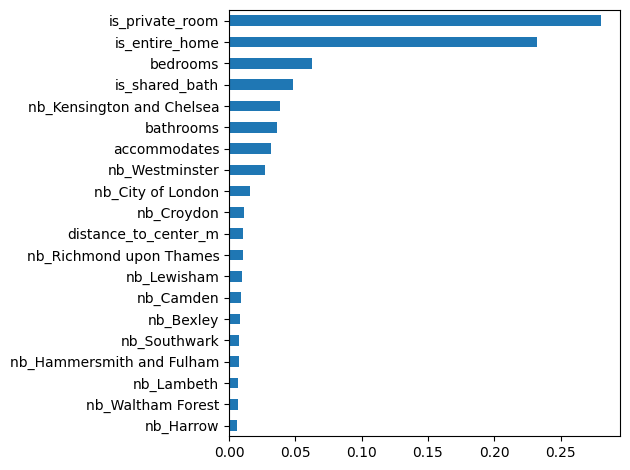

In [26]:
importances = pd.Series(final_model.feature_importances_, index=X.columns)
importances.sort_values().tail(20).plot(kind='barh')
plt.tight_layout()
plt.show()

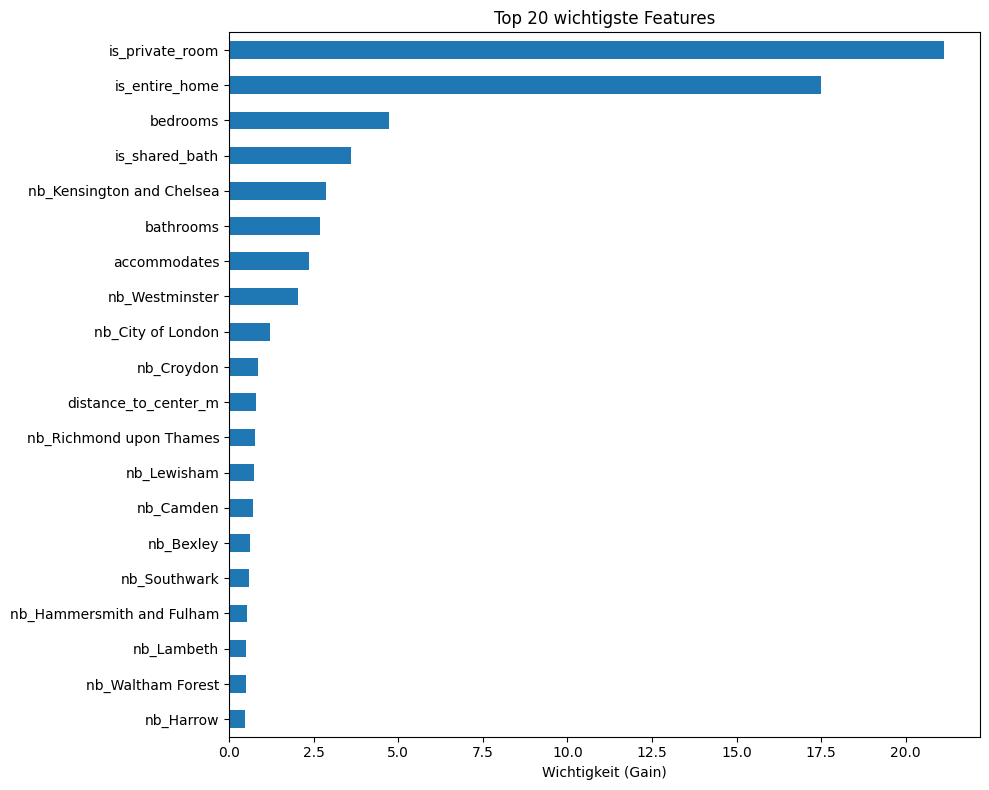

In [27]:
# Feature-Importance nach "Gain" – durchschnittliche Reduktion des Vorhersagefehlers pro Feature.
# Aussagekräftiger als die Standard-"Weight"-Metrik, die nur Verzweigungen zählt.
booster = final_model.get_booster()
booster.feature_names = list(X.columns)

importance_dict = booster.get_score(importance_type='gain')
importances = pd.Series(importance_dict).sort_values()

importances.tail(20).plot(kind='barh', figsize=(10, 8))
plt.xlabel('Wichtigkeit (Gain)')
plt.title('Top 20 wichtigste Features')
plt.tight_layout()
plt.show()

### 5.2 Lineare Regression

**Funktionsweise:** Schätzt einen globalen Koeffizienten pro Merkmal unter der Annahme eines linearen Zusammenhangs mit dem (log-)Preis. Das schnellste und interpretierbarste Modell.

**Vorteile:** Vollständig interpretierbar, keine Hyperparameter, sehr schnelles Training.

**Nachteile:** Kann nichtlineare Zusammenhänge und Merkmalsinteraktionen nicht erfassen. Bei korrelierten Merkmalen werden Koeffizienten instabil (Multikollinearität).

*Die inferenzstatistische Auswertung (Koeffizienten, p-Werte, R²) erfolgte in Abschnitt 4. Hier dient das Modell als Benchmark für den ML-Vergleich.*

In [28]:
# ── Lineare Regression ────────────────────────────────────────────────────────
# Einfachstes Basismodell: nimmt einen linearen Zusammenhang zwischen jedem Feature
# und dem (log-)Preis an. Keine Hyperparameter zu optimieren.

rmse_lr = []

for seed in seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    model_lr = LinearRegression()
    model_lr.fit(X_train_s_scaled, y_train_s)

    y_pred = np.expm1(model_lr.predict(X_test_s_scaled))
    y_true = np.expm1(y_test_s)
    rmse   = root_mean_squared_error(y_true, y_pred)

    rmse_lr.append(rmse)
    print(f"Seed {seed:>3}: Test-RMSE = ${rmse:.2f}")

print(f"\nLineare Regression   —  Mittlerer RMSE: ${np.mean(rmse_lr):.2f}  ±  ${np.std(rmse_lr):.2f}")

Seed   1: Test-RMSE = $82.60
Seed   7: Test-RMSE = $86.39
Seed  42: Test-RMSE = $86.44
Seed  67: Test-RMSE = $86.89


Seed  99: Test-RMSE = $82.83

Lineare Regression   —  Mittlerer RMSE: $85.03  ±  $1.90


### 5.3 Ridge-Regression

**Funktionsweise:** Wie die lineare Regression, aber mit L2-Regularisierung: ein Strafterm λ·‖β‖² bestraft große Koeffizienten und reduziert Überanpassung.

**Vorteile:** Stabiler als OLS bei korrelierten Merkmalen (z. B. Stadtteil-Dummies). Der Regularisierungsparameter α wird automatisch per 5-facher Kreuzvalidierung aus dem Gitter {0,01 … 1.000} gewählt.

**Warum Ridge ≈ Lineare Regression?** Mit n >> p (viele Zeilen, wenige Merkmale) sind OLS-Schätzer bereits stabil. Der gewählte α = 10 bewirkt auf standardisierten Merkmalen nur minimale Koeffizientenänderungen – daher der nahezu identische RMSE. Ridge entfaltet seinen Vorteil bei p ≈ n oder stärkerer Multikollinearität.

In [29]:
# ── Ridge-Regression ──────────────────────────────────────────────────────────
# Wie lineare Regression, aber mit L2-Strafterm, der große Koeffizienten verkleinert.
# Reduziert Überanpassung bei korrelierten Features (z. B. unsere Stadtteil-Dummies).
# RidgeCV wählt die optimale Stärke (Alpha) automatisch per 5-facher Kreuzvalidierung.

ALPHAS = [0.01, 0.1, 1.0, 10.0, 100.0, 1000.0]

rmse_ridge = []

for seed in seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    model_ridge = RidgeCV(alphas=ALPHAS, cv=5)
    model_ridge.fit(X_train_s_scaled, y_train_s)

    y_pred = np.expm1(model_ridge.predict(X_test_s_scaled))
    y_true = np.expm1(y_test_s)
    rmse   = root_mean_squared_error(y_true, y_pred)

    rmse_ridge.append(rmse)
    print(f"Seed {seed:>3}: Test-RMSE = ${rmse:.2f}  (bestes Alpha = {model_ridge.alpha_})")

print(f"\nRidge-Regression     —  Mittlerer RMSE: ${np.mean(rmse_ridge):.2f}  ±  ${np.std(rmse_ridge):.2f}")

Seed   1: Test-RMSE = $82.60  (bestes Alpha = 10.0)


Seed   7: Test-RMSE = $86.40  (bestes Alpha = 10.0)


Seed  42: Test-RMSE = $86.45  (bestes Alpha = 10.0)


Seed  67: Test-RMSE = $86.89  (bestes Alpha = 10.0)


Seed  99: Test-RMSE = $82.83  (bestes Alpha = 10.0)

Ridge-Regression     —  Mittlerer RMSE: $85.03  ±  $1.90


### 5.4 Neuronales Netz (MLP)

**Funktionsweise:** Ein mehrschichtiges Perzeptron mit drei verdeckten Schichten (256 → 128 → 64 Neuronen) und ReLU-Aktivierung. Es lernt nichtlineare Merkmalskombinationen durch Rückpropagation des Fehlers.

**Vorteile:** Kann komplexe nichtlineare Muster und Interaktionen modellieren; skaliert gut mit wachsender Datenmenge.

**Nachteile:** Rechenintensiver als lineare Modelle; empfindlich gegenüber Merkmalsskalierung (StandardScaler ist hier entscheidend); wenig interpretierbar.

**Konfiguration:** Early Stopping auf einem internen Validierungsanteil von 10 % verhindert Überanpassung; maximal 500 Epochen.

In [30]:
# ── Neuronales Netz ───────────────────────────────────────────────────────────
# Ein mehrschichtiges Perzeptron (MLP) mit drei verdeckten Schichten.
# Es lernt nichtlineare Merkmalskombinationen – ausdrucksstärker als lineare Modelle,
# aber auch langsamer im Training.
#
# Architektur:  Eingabe → 256 → 128 → 64 → Ausgabe
#
# early_stopping=True reserviert 10 % der Trainingsdaten zur internen Validierung
# und stoppt das Training, wenn keine Verbesserung mehr eintritt (verhindert Überanpassung).

rmse_nn = []

for seed in seeds:
    X_train_s, X_test_s, y_train_s, y_test_s = train_test_split(X, y, test_size=0.2, random_state=seed)

    scaler_s = StandardScaler()
    X_train_s_scaled = scaler_s.fit_transform(X_train_s)
    X_test_s_scaled  = scaler_s.transform(X_test_s)

    model_nn = MLPRegressor(
        hidden_layer_sizes=(256, 128, 64),
        activation='relu',
        max_iter=500,
        early_stopping=True,
        validation_fraction=0.1,
        random_state=seed,
        verbose=False,
    )
    model_nn.fit(X_train_s_scaled, y_train_s)

    y_pred = np.expm1(model_nn.predict(X_test_s_scaled))
    y_true = np.expm1(y_test_s)
    rmse   = root_mean_squared_error(y_true, y_pred)

    rmse_nn.append(rmse)
    print(f"Seed {seed:>3}: Test-RMSE = ${rmse:.2f}")

print(f"\nNeuronales Netz      —  Mittlerer RMSE: ${np.mean(rmse_nn):.2f}  ±  ${np.std(rmse_nn):.2f}")

Seed   1: Test-RMSE = $77.65


Seed   7: Test-RMSE = $79.87


Seed  42: Test-RMSE = $79.96


Seed  67: Test-RMSE = $79.73


Seed  99: Test-RMSE = $75.99

Neuronales Netz      —  Mittlerer RMSE: $78.64  ±  $1.58


### 5.5 Modellvergleich

Alle vier Modelle werden nach ihrem mittleren Test-RMSE (über 5 Seeds) verglichen. Ein niedriger RMSE bedeutet, dass die Vorhersagen im Durchschnitt näher am tatsächlichen Preis liegen.

Modell                  Mittl. RMSE ($)    Std ($)
──────────────────────────────────────────────────
XGBoost                $         71.17   ±$  1.55
Neuronales Netz        $         78.64   ±$  1.58
Lineare Regression     $         85.03   ±$  1.90
Ridge-Regression       $         85.03   ±$  1.90


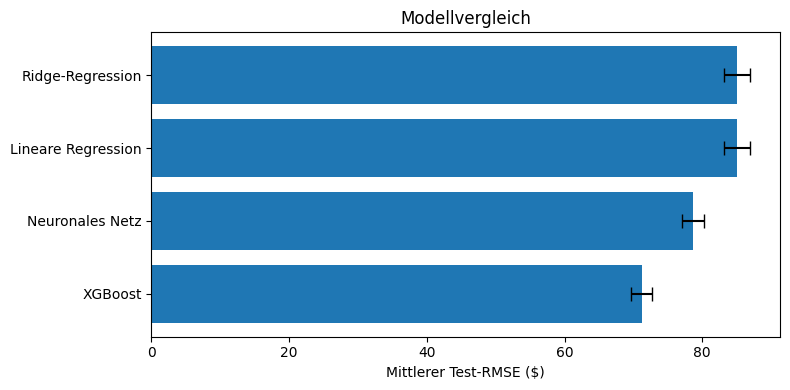

In [31]:
# ── Modellvergleich ───────────────────────────────────────────────────────────
# Übersicht aller Modelle, sortiert nach mittlerem RMSE (kleiner = besser).

results = {
    'Lineare Regression': rmse_lr,
    'Ridge-Regression':   rmse_ridge,
    'Neuronales Netz':    rmse_nn,
    'XGBoost':            rmse_scores,
}

print(f"{'Modell':<22} {'Mittl. RMSE ($)':>16} {'Std ($)':>10}")
print("─" * 50)
for name, scores in sorted(results.items(), key=lambda x: np.mean(x[1])):
    print(f"{name:<22} ${np.mean(scores):>14.2f}   ±${np.std(scores):>6.2f}")

# Balkendiagramm zum visuellen Vergleich
means = [np.mean(v) for v in results.values()]
stds  = [np.std(v)  for v in results.values()]
names = list(results.keys())

order = np.argsort(means)
plt.figure(figsize=(8, 4))
plt.barh(
    [names[i] for i in order],
    [means[i] for i in order],
    xerr=[stds[i] for i in order],
    capsize=5,
)
plt.xlabel('Mittlerer Test-RMSE ($)')
plt.title('Modellvergleich')
plt.tight_layout()
plt.show()

## 6. Kritische Bewertung

Modell                  Vorher ($) Nachher ($)  Änderung
──────────────────────────────────────────────────────────
XGBoost                  $   74.92   $   71.17   ▼ 3.75
Neuronales Netz          $   84.40   $   78.64   ▼ 5.76
Lineare Regression       $   87.85   $   85.03   ▼ 2.82
Ridge-Regression         $   87.85   $   85.03   ▼ 2.82


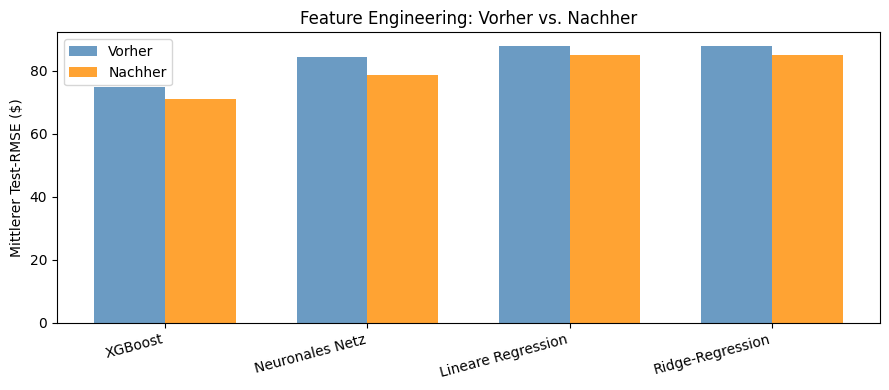

In [32]:
# ── Vorher vs. Nachher: Einfluss des Feature Engineerings ─────────────────────
# Diese Basiswerte wurden VOR den Feature-Verbesserungen aufgezeichnet:
#   - enthielt has_wifi (98,3 % konstant) und has_kitchen (91,5 % konstant)
#   - enthielt beds (Korr. 0,805 mit accommodates – redundant)
#   - verwendete review_scores_rating (Korr. +0,032) statt review_scores_location (+0,132)
#   - fehlte calculated_host_listings_count (Korr. +0,218, stärkstes ungenutztes Signal)

baseline = {
    'XGBoost':            74.92,
    'Neuronales Netz':    84.40,
    'Lineare Regression': 87.85,
    'Ridge-Regression':   87.85,
}
after = {
    'XGBoost':            np.mean(rmse_scores),
    'Neuronales Netz':    np.mean(rmse_nn),
    'Lineare Regression': np.mean(rmse_lr),
    'Ridge-Regression':   np.mean(rmse_ridge),
}

print(f"{'Modell':<22} {'Vorher ($)':>11} {'Nachher ($)':>11} {'Änderung':>9}")
print("─" * 58)
for name in ['XGBoost', 'Neuronales Netz', 'Lineare Regression', 'Ridge-Regression']:
    b, a = baseline[name], after[name]
    delta = a - b
    tag = f"{'▼' if delta < 0 else '▲'} {abs(delta):.2f}"
    print(f"{name:<22}   ${b:>8.2f}   ${a:>8.2f}   {tag}")

# Gruppiertes Balkendiagramm
models = list(baseline.keys())
x = np.arange(len(models))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 4))
ax.bar(x - width / 2, [baseline[m] for m in models], width, label='Vorher',  color='steelblue',  alpha=0.8)
ax.bar(x + width / 2, [after[m]    for m in models], width, label='Nachher', color='darkorange', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(models, rotation=15, ha='right')
ax.set_ylabel('Mittlerer Test-RMSE ($)')
ax.set_title('Feature Engineering: Vorher vs. Nachher')
ax.legend()
plt.tight_layout()
plt.show()

### Zusammenfassung und Diskussion

**Modellhierarchie:** XGBoost erzielt den niedrigsten RMSE und übertrifft alle anderen Modelle deutlich. Das Neuronale Netz liegt auf Platz zwei. Lineare und Ridge-Regression liefern nahezu identische Ergebnisse (vgl. Abschnitt 5.3).

**Robustheit:** Die 5-Seed-Auswertung zeigt eine stabile Modellreihenfolge bei jedem Seed. Die Standardabweichungen deuten auf moderate, erwartbare Varianz hin.

**Ridge = Lineare Regression:** Der nahezu identische RMSE ist statistisch erwartet: bei n >> p sind OLS-Schätzer bereits stabil, und die Regularisierung bewirkt kaum Koeffizientenänderungen. Ridge hätte einen größeren Effekt bei p ≈ n oder stärkerer Multikollinearität.

---

### Limitierungen des Datensatzes

| Fehlende Variable | Erwarteter Einfluss |
|---|---|
| Fotoqualität | Professionelle Fotos erzielen nachweislich höhere Preise |
| Saisonalität / Buchungsdatum | Preise variieren stark nach Saison und Events |
| Bewertungstext-Sentiment | Qualitative Nuancen jenseits numerischer Scores |
| Exakte Adresse / Straße | Feinkörnigere Lagesignale als der Stadtbezirk |
| Buchungsvolumen (Beliebtheit) | Direkte Nachfrageinformation fehlt |
| Renovierungsjahr / Gebäudezustand | Qualitätsindikator der Unterkunft fehlt |

---

### Implikationen

**Für Gastgeber:** Feature Importance und Regressions­koeffizienten zeigen, dass Unterkunftstyp (gesamte Wohnung vs. Zimmer), Kapazität und Lage (Stadtbezirk + Entfernung zum Zentrum) die stärksten Preistreiber sind. Die Ausstattungsanzahl hat einen messbaren, aber kleineren Einfluss.

**Für die Plattform:** Die geografische Preiskarte zeigt eine deutliche Konzentration hoher Preise in Innenstadt­bezirken (Westminster, Kensington, Camden). Eine modellbasierte Preisempfehlung könnte Gastgebern helfen, den Marktpreis besser einzuschätzen.

**Methodisch:** XGBoost liefert den besten RMSE, ist aber eine Black Box. Eine **SHAP-Analyse** (SHapley Additive exPlanations) würde den Beitrag jedes Merkmals für jede individuelle Vorhersage quantifizieren und die Interpretierbarkeit erhöhen.